# Comparação entre simulação OpenDSS Puro e Co-simulação Mosaik

O sistema utilizado em estudo consiste no sistema de 123 barras do IEEE.

Entre as condiçõos o qual simulações foram performadas, destaca-se

- Controle dos reguladores de tensão desabilitados
- Modo de controle = Time
- Simulação de 24 horas ao passo de 5 minutos

O comparativo analisa os resultados do comportamento deste sistema na com e sem presenção de um sistema fotovoltaico, a saber o elemento PVSystem utilizado é

```bash
New PVSystem.PV phases=3 Bus1=97 kV=4.16 kVA=1000 irrad=0.8 Pmpp=1000
~ temperature=25 PF=1 EffCurve=MyEff P-TCurve=MyPvsT
~ Daily=my_shape2_pv TDaily=MyTemp
~ Vminpu=0.001
~ Model=1
```

Por fim, utiliza-se uma métrica de rmse e mae para analisar a diferença entre as grandezas obtidas por opendss puro e co-simulação mosaik

## Dominio do OpenDSS puro

In [4]:
# Standard library
import os
from pathlib import Path
import math
from collections import defaultdict
import re
import random
from tqdm import tqdm
import datetime as dt

# Third-party
import py_dss_interface
from simulators.api_opendss import OpenDSS
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [5]:
BASE_DIR = Path("..").resolve()
BASE_DIR

PosixPath('/mnt/c/Users/pvict/documents/UFC/GREI/GREI_Projeto_OpenTES/tsre/tsre-der-opentes/src')

In [6]:
DSS_FILE = BASE_DIR / 'data' / '123Bus' / 'run_ieee123_cosim_5min.dss'

In [7]:
# Criando a instância
dss_w = OpenDSS(
    redirects=DSS_FILE,
    time_step=dt.timedelta(minutes=15),
    start_time=dt.datetime(2024, 1, 1, 0, 0),
    fail_on_error=True
)

2026-04-10 00:38:10.069196 - DSS: Compiling...
Waiting...
Actor 1: Job done
>>2026-04-10 00:38:10.435706 - DSS: Compiled Circuit: ieee123


In [8]:
dss_w.get_power(name='L115', element='Line')

((1395.4629411087967, 935.9705942368456, 1151.2501442621408),
 (589.373510804264, 353.15263044664886, 415.51022690197067))

In [9]:
dss = py_dss_interface.DSS()


In [10]:
DSS_FILE = BASE_DIR / 'data' / '123Bus' / 'run_ieee123_cosim_5min.dss'

dss.text('Clear')
dss.text(f"Compile '{DSS_FILE}'")
dss.text("Solve")

dss.circuit.set_active_bus('149')
kv_149 = dss.bus.kv_base * 1000

dss.monitors.name = 'feeder_output_vi'

l115_va_mag = [v/kv_149 for v in dss.monitors.channel(1)]
l115_vb_mag = [v/kv_149 for v in dss.monitors.channel(3)]
l115_vc_mag = [v/kv_149 for v in dss.monitors.channel(5)]

dss.monitors.name = 'feeder_output_pq'

l115_pa = dss.monitors.channel(1)
l115_qa = dss.monitors.channel(2)
l115_pb = dss.monitors.channel(3)
l115_qb = dss.monitors.channel(4)
l115_pc = dss.monitors.channel(5)
l115_qc = dss.monitors.channel(6)

dss.circuit.set_active_bus('97')
kv_97 = dss.bus.kv_base * 1000

dss.monitors.name = 'line96_vi'
bus97_va = [v/kv_97 for v in dss.monitors.channel(1)]
bus97_vb = [v/kv_97 for v in dss.monitors.channel(3)]
bus97_vc = [v/kv_97 for v in dss.monitors.channel(5)]

dss.circuit.set_active_bus('29')
kv_29 = dss.bus.kv_base * 1000

dss.monitors.name = 'line31_vi'
bus29_va = [v/kv_29 for v in dss.monitors.channel(1)]
bus29_vb = [v/kv_29 for v in dss.monitors.channel(3)]
bus29_vc = [v/kv_29 for v in dss.monitors.channel(5)]

# Barramento 114
dss.circuit.set_active_bus('114')
kv_114 = dss.bus.kv_base * 1000

dss.monitors.name = 'line113_vi'
bus114_va = [v/kv_114 for v in dss.monitors.channel(1)]
bus114_vb = [v/kv_114 for v in dss.monitors.channel(3)]
bus114_vc = [v/kv_114 for v in dss.monitors.channel(5)]

# Barramento 92
dss.circuit.set_active_bus('92')
kv_92 = dss.bus.kv_base * 1000

dss.monitors.name = 'line91_vi'
bus92_va = [v/kv_92 for v in dss.monitors.channel(1)]
bus92_vb = [v/kv_92 for v in dss.monitors.channel(3)]
bus92_vc = [v/kv_92 for v in dss.monitors.channel(5)]

# Barramento 20
dss.circuit.set_active_bus('20')
kv_20 = dss.bus.kv_base * 1000

dss.monitors.name = 'line20_vi'
bus20_va = [v/kv_20 for v in dss.monitors.channel(1)]
bus20_vb = [v/kv_20 for v in dss.monitors.channel(3)]
bus20_vc = [v/kv_20 for v in dss.monitors.channel(5)]

# Barramento 52
dss.circuit.set_active_bus('52')
kv_52 = dss.bus.kv_base * 1000

dss.monitors.name = 'line52_vi'
bus52_va = [v/kv_52 for v in dss.monitors.channel(1)]
bus52_vb = [v/kv_52 for v in dss.monitors.channel(3)]
bus52_vc = [v/kv_52 for v in dss.monitors.channel(5)]

# Barramento 151
dss.circuit.set_active_bus('151')
kv_151 = dss.bus.kv_base * 1000

dss.monitors.name = 'line51_vi'
bus151_va = [v/kv_151 for v in dss.monitors.channel(1)]
bus151_vb = [v/kv_151 for v in dss.monitors.channel(3)]
bus151_vc = [v/kv_151 for v in dss.monitors.channel(5)]

# Barramento 85
dss.circuit.set_active_bus('85')
kv_85 = dss.bus.kv_base * 1000

dss.monitors.name = 'line85_vi'
bus85_va = [v/kv_85 for v in dss.monitors.channel(1)]
bus85_vb = [v/kv_85 for v in dss.monitors.channel(3)]
bus85_vc = [v/kv_85 for v in dss.monitors.channel(5)]

Actor 1 terminated
>>Waiting...
Actor 1: Job done
>>5004 OpenDSS 
Monitor "line20_vi" Not Found in Active Circuit.
5004 OpenDSS 
Monitor "line52_vi" Not Found in Active Circuit.
5004 OpenDSS 
Monitor "line51_vi" Not Found in Active Circuit.
5004 OpenDSS 
Monitor "line85_vi" Not Found in Active Circuit.


In [11]:
DSS_FILE = BASE_DIR / 'data' / '123Bus' / 'run_ieee123_cosim_pv_5min.dss'

dss.text('Clear')
dss.text(f"Compile '{DSS_FILE}'")
dss.text("Solve")

dss.circuit.set_active_bus('149')
kv_149 = dss.bus.kv_base * 1000

dss.monitors.name = 'feeder_output_vi'

l115_va_mag_pv = [v/kv_149 for v in dss.monitors.channel(1)]
l115_vb_mag_pv = [v/kv_149 for v in dss.monitors.channel(3)]
l115_vc_mag_pv = [v/kv_149 for v in dss.monitors.channel(5)]

dss.monitors.name = 'feeder_output_pq'

l115_pa_pv = dss.monitors.channel(1)
l115_qa_pv = dss.monitors.channel(2)
l115_pb_pv = dss.monitors.channel(3)
l115_qb_pv = dss.monitors.channel(4)
l115_pc_pv = dss.monitors.channel(5)
l115_qc_pv = dss.monitors.channel(6)

dss.circuit.set_active_bus('97')
kv_97 = dss.bus.kv_base * 1000

dss.monitors.name = 'line96_vi'
bus97_va_pv = [v/kv_97 for v in dss.monitors.channel(1)]
bus97_vb_pv = [v/kv_97 for v in dss.monitors.channel(3)]
bus97_vc_pv = [v/kv_97 for v in dss.monitors.channel(5)]

dss.circuit.set_active_bus('29')
kv_29 = dss.bus.kv_base * 1000

dss.monitors.name = 'line31_vi'
bus29_va_pv = [v/kv_29 for v in dss.monitors.channel(1)]
bus29_vb_pv = [v/kv_29 for v in dss.monitors.channel(3)]
bus29_vc_pv = [v/kv_29 for v in dss.monitors.channel(5)]

# Barramento 114
dss.circuit.set_active_bus('114')
kv_114 = dss.bus.kv_base * 1000

dss.monitors.name = 'line113_vi'
bus114_va_pv = [v/kv_114 for v in dss.monitors.channel(1)]
bus114_vb_pv = [v*0 for v in dss.monitors.channel(1)]
bus114_vc_pv = [v*0 for v in dss.monitors.channel(1)]

# Barramento 92
dss.circuit.set_active_bus('92')
kv_92 = dss.bus.kv_base * 1000

dss.monitors.name = 'line91_vi'
bus92_va_pv = [v*0 for v in dss.monitors.channel(1)]
bus92_vb_pv = [v*0 for v in dss.monitors.channel(1)]
bus92_vc_pv = [v/kv_92 for v in dss.monitors.channel(1)]

# # Barramento 20
# dss.circuit.set_active_bus('20')
# kv_20 = dss.bus.kv_base * 1000

# dss.monitors.name = 'line20_vi'
# bus20_va_pv = [v/kv_20 for v in dss.monitors.channel(1)]
# bus20_vb_pv = [v/kv_20 for v in dss.monitors.channel(3)]
# bus20_vc_pv = [v/kv_20 for v in dss.monitors.channel(5)]

# # Barramento 52
# dss.circuit.set_active_bus('52')
# kv_52 = dss.bus.kv_base * 1000

# dss.monitors.name = 'line52_vi'
# bus52_va_pv = [v/kv_52 for v in dss.monitors.channel(1)]
# bus52_vb_pv = [v/kv_52 for v in dss.monitors.channel(3)]
# bus52_vc_pv = [v/kv_52 for v in dss.monitors.channel(5)]

# # Barramento 151
# dss.circuit.set_active_bus('151')
# kv_151 = dss.bus.kv_base * 1000

# dss.monitors.name = 'line51_vi'
# bus151_va_pv = [v/kv_151 for v in dss.monitors.channel(1)]
# bus151_vb_pv = [v/kv_151 for v in dss.monitors.channel(3)]
# bus151_vc_pv = [v/kv_151 for v in dss.monitors.channel(5)]

# # Barramento 85
# dss.circuit.set_active_bus('85')
# kv_85 = dss.bus.kv_base * 1000

# dss.monitors.name = 'line85_vi'
# bus85_va_pv = [v/kv_85 for v in dss.monitors.channel(1)]
# bus85_vb_pv = [v/kv_85 for v in dss.monitors.channel(3)]
# bus85_vc_pv = [v/kv_85 for v in dss.monitors.channel(5)]

dss.monitors.name = 'pv_output'
pa_pv = [-1*p for p in dss.monitors.channel(1)]
qa_pv = dss.monitors.channel(2)
pb_pv = [-1*p for p in dss.monitors.channel(3)]
qb_pv = dss.monitors.channel(4)
pc_pv = [-1*p for p in dss.monitors.channel(5)]
qc_pv = dss.monitors.channel(6)


Actor 1 terminated
>>Waiting...
Actor 1: Job done
>>

In [12]:
dss.loadshapes.name = 'my_shape2_pv'
irradiancia = dss.loadshapes.p_mult

temperatura = dss.text('? TShape.mytemp.temp')
temperatura

'[ 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25 25.8333 26.6667 27.5 28.3333 29.1667 30 30.8333 31.6667 32.5 33.3333 34.1667 35 35.4167 35.8333 36.25 36.6667 37.0833 37.5 37.9167 38.3333 38.75 39.1667 39.5833 40 40.4167 40.8333 41.25 41.6667 42.0833 42.5 42.9167 43.3333 43.75 44.1667 44.5833 45 45.4167 45.8333 46.25 46.6667 47.0833 47.5 47.9167 48.3333 48.75 49.1667 49.5833 50 50.8333 51.6667 52.5 53.3333 54.1667 55 55.8333 56.6667 57.5 58.3333 59.1667 60 60 60 60 60 60 60 60 60 60 60 60 60 59.5833 59.1667 58.75 58.3333 57.9167 57.5 57.0833 56.6667 56.25 55.8333 55.4167 55 53.75 52.5 51.25 50 48.75 47.5 46.25 45 43.75 42.5 41.25 40 39.5833 39.1667 38.75 38.3333 37.9167 37.5 37.0833 36.6667 36.25 35.8333 35.4167 35 34.5833 34.1667 33.75 33.3333 32.9167 32.5 32.0833 31.6667 31.25 3

In [13]:
temperatura = [float(x) for x in temperatura[2:-1:1].split()]
len(temperatura)

288

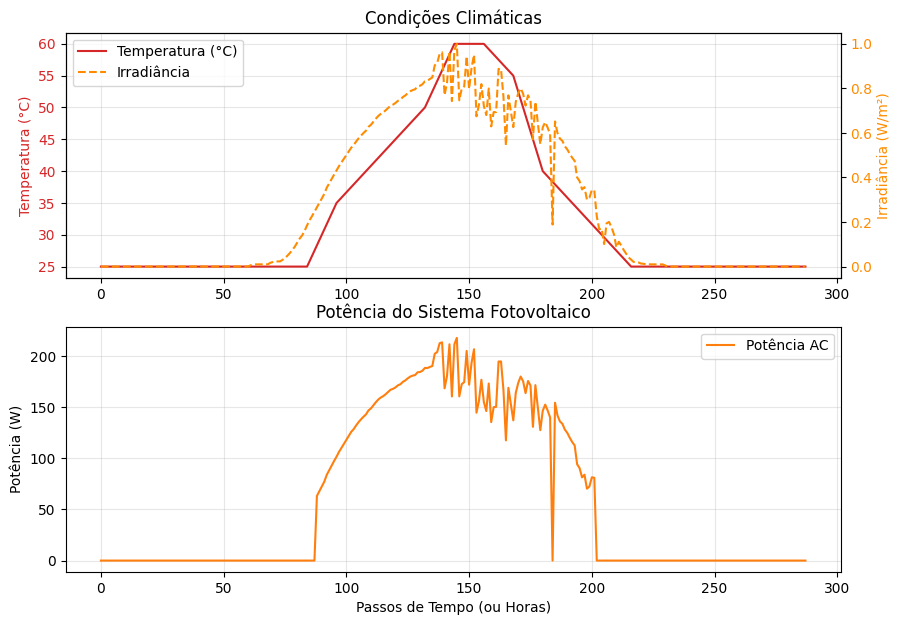

In [14]:
# Criação da figura com um tamanho um pouco maior para acomodar rótulos
fig, axs = plt.subplots(2, 1, figsize=(10, 7))

# --- PLOT 1: Temperatura e Irradiância ---
# Usar 'tab:red' (vermelho) para temperatura dá um bom contraste
linha1 = axs[0].plot(temperatura, label='Temperatura (°C)', color='tab:red', linestyle='-')
axs[0].set_ylabel('Temperatura (°C)', color='tab:red')
axs[0].tick_params(axis='y', labelcolor='tab:red')

# Criando o eixo secundário
ax0_twin = axs[0].twinx()
# Usar 'darkorange' ou 'gold' no lugar de 'yellow' melhora muito a visualização
linha2 = ax0_twin.plot(irradiancia, label='Irradiância', color='darkorange', linestyle='--')
ax0_twin.set_ylabel('Irradiância (W/m²)', color='darkorange')
ax0_twin.tick_params(axis='y', labelcolor='darkorange')

# Juntando as legendas dos dois eixos (axs[0] e ax0_twin) em uma só caixa
linhas_plot1 = linha1 + linha2
labels_plot1 = [l.get_label() for l in linhas_plot1]
axs[0].legend(linhas_plot1, labels_plot1, loc='upper left')

axs[0].set_title('Condições Climáticas', fontsize=12)
axs[0].grid(True, alpha=0.3)


# --- PLOT 2: Potência DC e AC ---
axs[1].plot(pa_pv, label='Potência AC', color='tab:orange', linestyle='-')
# axs[1].plot(inv_pac_cosim, label='Potência AC', color='tab:blue', linestyle='--') # Mudei de dashdot para -- para ficar mais limpo

axs[1].set_ylabel('Potência (W)') # Ajuste a unidade conforme seus dados
axs[1].set_xlabel('Passos de Tempo (ou Horas)')
axs[1].legend(loc='upper right')

axs[1].set_title('Potência do Sistema Fotovoltaico', fontsize=12)
axs[1].grid(True, alpha=0.3)

# --- AJUSTES FINAIS ---
# Ajusta o layout para evitar que os rótulos de um gráfico fiquem em cima do outro
# fig.tight_layout()

plt.show()

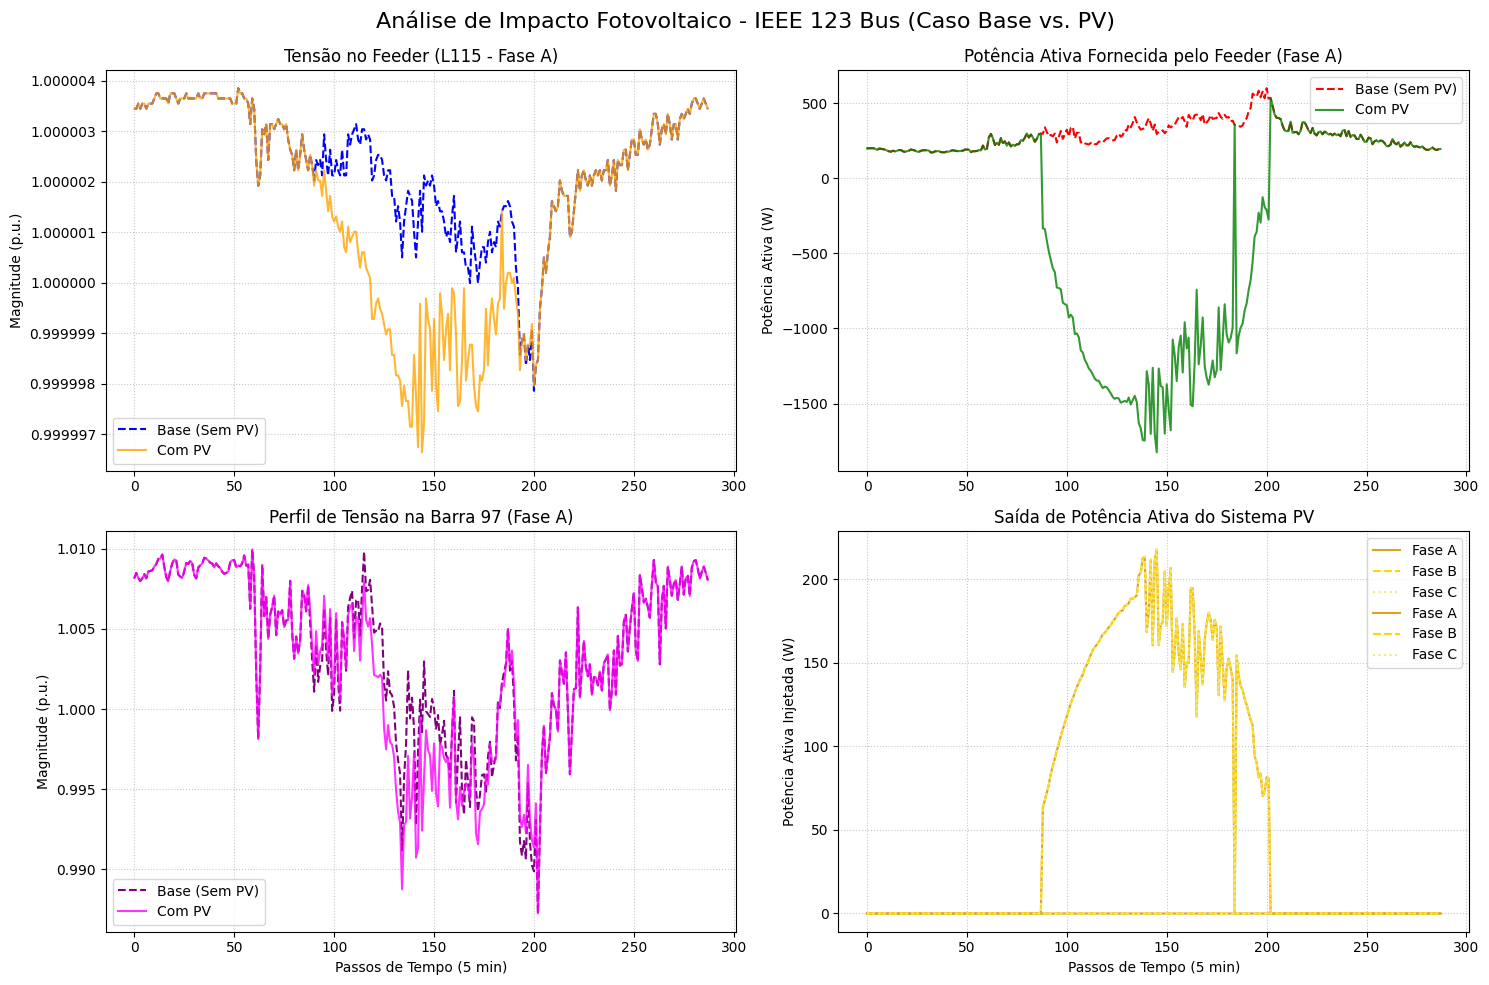

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Cria um eixo x baseado no número de pontos (passos de 5 minutos)
# Assumindo que todos os canais têm o mesmo tamanho
passos = range(len(l115_va_mag))

# Cria uma figura com uma grade 2x2 de subgráficos
fig, axs = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Análise de Impacto Fotovoltaico - IEEE 123 Bus (Caso Base vs. PV)', fontsize=16)

# 1. Comparação de Tensão no Feeder (L115 - Fase A)
axs[0, 0].plot(passos, l115_va_mag, label='Base (Sem PV)', color='blue', linestyle='--')
axs[0, 0].plot(passos, l115_va_mag_pv, label='Com PV', color='orange', alpha=0.8)
axs[0, 0].set_title('Tensão no Feeder (L115 - Fase A)')
axs[0, 0].set_ylabel('Magnitude (p.u.)')
axs[0, 0].grid(True, linestyle=':', alpha=0.7)
# Desativa o offset e a notação científica no eixo y
axs[0, 0].ticklabel_format(useOffset=False, style='plain', axis='y')
axs[0, 0].legend()

# 2. Comparação de Potência Ativa no Feeder (L115 - Fase A)
axs[0, 1].plot(passos, l115_pa, label='Base (Sem PV)', color='red', linestyle='--')
axs[0, 1].plot(passos, l115_pa_pv, label='Com PV', color='green', alpha=0.8)
axs[0, 1].set_title('Potência Ativa Fornecida pelo Feeder (Fase A)')
axs[0, 1].set_ylabel('Potência Ativa (W)')
axs[0, 1].grid(True, linestyle=':', alpha=0.7)
axs[0, 1].legend()

# 3. Comparação de Tensão na Barra 97 (Fase A)
axs[1, 0].plot(passos, bus97_va, label='Base (Sem PV)', color='purple', linestyle='--')
axs[1, 0].plot(passos, bus97_va_pv, label='Com PV', color='magenta', alpha=0.8)
axs[1, 0].set_title('Perfil de Tensão na Barra 97 (Fase A)')
axs[1, 0].set_xlabel('Passos de Tempo (5 min)')
axs[1, 0].set_ylabel('Magnitude (p.u.)')
axs[1, 0].grid(True, linestyle=':', alpha=0.7)
axs[1, 0].legend()

# 4. Geração do Sistema PV (Potência Ativa nas 3 Fases)
axs[1, 1].plot(passos, pa_pv, label='Fase A', color='goldenrod')
axs[1, 1].plot(passos, pb_pv, label='Fase B', color='gold', linestyle='--')
axs[1, 1].plot(passos, pc_pv, label='Fase C', color='khaki', linestyle=':')
axs[1, 1].plot(passos, qa_pv, label='Fase A', color='goldenrod')
axs[1, 1].plot(passos, qb_pv, label='Fase B', color='gold', linestyle='--')
axs[1, 1].plot(passos, qc_pv, label='Fase C', color='khaki', linestyle=':')
axs[1, 1].set_title('Saída de Potência Ativa do Sistema PV')
axs[1, 1].set_xlabel('Passos de Tempo (5 min)')
axs[1, 1].set_ylabel('Potência Ativa Injetada (W)')
axs[1, 1].grid(True, linestyle=':', alpha=0.7)
axs[1, 1].legend()

# Ajusta o layout para evitar sobreposição de textos
plt.tight_layout()
plt.subplots_adjust(top=0.92) # Dá um espaço para o título principal
plt.show()

## Co-simulação Mosaik

In [16]:
df_cosim = pd.read_csv(BASE_DIR / 'output' / 'result_run_ieee123_cosim_5min.csv')

l115_va_mag_cosim = df_cosim['DSS-0.Bus-149-V1_pu']
l115_vb_mag_cosim = df_cosim['DSS-0.Bus-149-V2_pu']
l115_vc_mag_cosim = df_cosim['DSS-0.Bus-149-V3_pu']

l115_pa_cosim = df_cosim['DSS-0.Line-l115-P1_w']
l115_qa_cosim = df_cosim['DSS-0.Line-l115-Q1_var']
l115_pb_cosim = df_cosim['DSS-0.Line-l115-P2_w']
l115_qb_cosim = df_cosim['DSS-0.Line-l115-Q2_var']
l115_pc_cosim = df_cosim['DSS-0.Line-l115-P3_w']
l115_qc_cosim = df_cosim['DSS-0.Line-l115-Q3_var']

bus97_va_cosim = df_cosim['DSS-0.Bus-97-V1_pu']
bus97_vb_cosim = df_cosim['DSS-0.Bus-97-V2_pu']
bus97_vc_cosim = df_cosim['DSS-0.Bus-97-V3_pu']

In [17]:
df_cosim_pv = pd.read_csv(BASE_DIR / 'output' / 'result_run_ieee123_cosim_pv_5min.csv')

l115_va_mag_pv_cosim = df_cosim_pv['DSS-0.Bus-149-V1_pu']
l115_vb_mag_pv_cosim = df_cosim_pv['DSS-0.Bus-149-V2_pu']
l115_vc_mag_pv_cosim = df_cosim_pv['DSS-0.Bus-149-V3_pu']

l115_pa_pv_cosim = df_cosim_pv['DSS-0.Line-l115-P1_w']
l115_qa_pv_cosim = df_cosim_pv['DSS-0.Line-l115-Q1_var']
l115_pb_pv_cosim = df_cosim_pv['DSS-0.Line-l115-P2_w']
l115_qb_pv_cosim = df_cosim_pv['DSS-0.Line-l115-Q2_var']
l115_pc_pv_cosim = df_cosim_pv['DSS-0.Line-l115-P3_w']
l115_qc_pv_cosim = df_cosim_pv['DSS-0.Line-l115-Q3_var']

bus97_va_pv_cosim = df_cosim_pv['DSS-0.Bus-97-V1_pu']
bus97_vb_pv_cosim = df_cosim_pv['DSS-0.Bus-97-V2_pu']
bus97_vc_pv_cosim = df_cosim_pv['DSS-0.Bus-97-V3_pu']

bus29_va_pv_cosim = df_cosim_pv['DSS-0.Bus-29-V1_pu']
bus29_vb_pv_cosim = df_cosim_pv['DSS-0.Bus-29-V2_pu']
bus29_vc_pv_cosim = df_cosim_pv['DSS-0.Bus-29-V3_pu']

bus114_va_pv_cosim = df_cosim_pv['DSS-0.Bus-114-V1_pu']
bus114_vb_pv_cosim = df_cosim_pv['DSS-0.Bus-114-V2_pu']
bus114_vc_pv_cosim = df_cosim_pv['DSS-0.Bus-114-V3_pu']

bus92_va_pv_cosim = df_cosim_pv['DSS-0.Bus-92-V1_pu']
bus92_vb_pv_cosim = df_cosim_pv['DSS-0.Bus-92-V2_pu']
bus92_vc_pv_cosim = df_cosim_pv['DSS-0.Bus-92-V3_pu']

pa_pv_cosim = df_cosim_pv['DSS-0.PVSystem-pv-P1']
qa_pv_cosim = df_cosim_pv['DSS-0.PVSystem-pv-Q1']
pb_pv_cosim = df_cosim_pv['DSS-0.PVSystem-pv-P2']
qb_pv_cosim = df_cosim_pv['DSS-0.PVSystem-pv-Q2']
pc_pv_cosim = df_cosim_pv['DSS-0.PVSystem-pv-P3']
qc_pv_cosim = df_cosim_pv['DSS-0.PVSystem-pv-Q3']

temperature_cosim = df_cosim_pv['PVSimulator-0.PVPanel_0-temperature']
irradiance_cosim = df_cosim_pv['PVSimulator-0.PVPanel_0-irradiance']

pv_dc_cosim = df_cosim_pv['PVSimulator-0.PVPanel_0-P_dc']
inv_pac_cosim = df_cosim_pv['DSS-0.PVSystem-pv-P_meas']

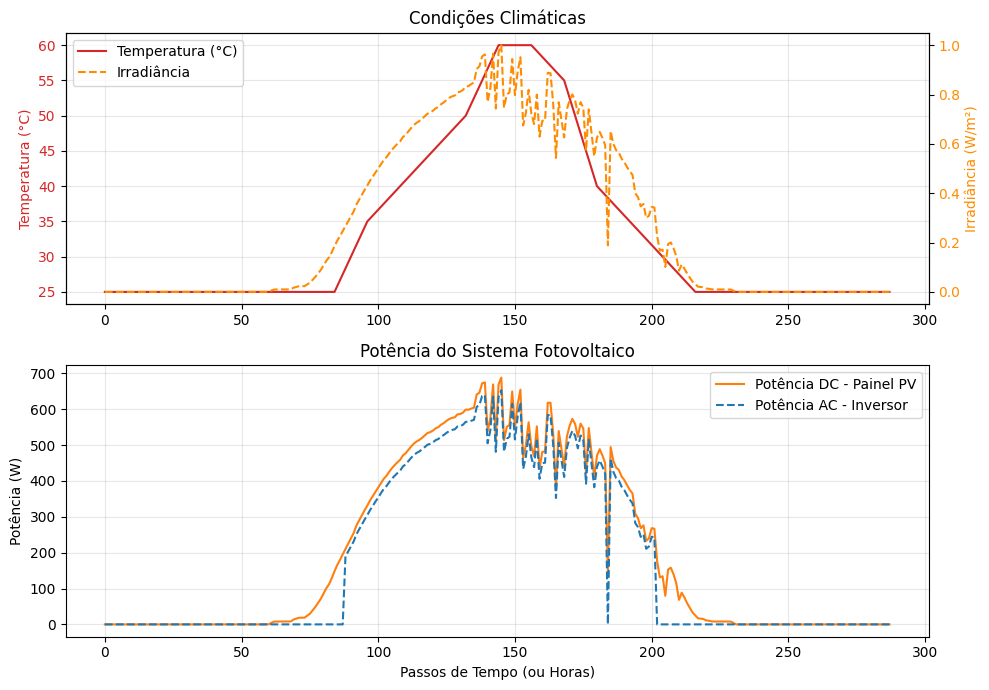

In [18]:
# Criação da figura com um tamanho um pouco maior para acomodar rótulos
fig, axs = plt.subplots(2, 1, figsize=(10, 7))

# --- PLOT 1: Temperatura e Irradiância ---
# Usar 'tab:red' (vermelho) para temperatura dá um bom contraste
linha1 = axs[0].plot(temperature_cosim, label='Temperatura (°C)', color='tab:red', linestyle='-')
axs[0].set_ylabel('Temperatura (°C)', color='tab:red')
axs[0].tick_params(axis='y', labelcolor='tab:red')

# Criando o eixo secundário
ax0_twin = axs[0].twinx()
# Usar 'darkorange' ou 'gold' no lugar de 'yellow' melhora muito a visualização
linha2 = ax0_twin.plot(irradiance_cosim, label='Irradiância', color='darkorange', linestyle='--')
ax0_twin.set_ylabel('Irradiância (W/m²)', color='darkorange')
ax0_twin.tick_params(axis='y', labelcolor='darkorange')

# Juntando as legendas dos dois eixos (axs[0] e ax0_twin) em uma só caixa
linhas_plot1 = linha1 + linha2
labels_plot1 = [l.get_label() for l in linhas_plot1]
axs[0].legend(linhas_plot1, labels_plot1, loc='upper left')

axs[0].set_title('Condições Climáticas', fontsize=12)
axs[0].grid(True, alpha=0.3)


# --- PLOT 2: Potência DC e AC ---
axs[1].plot(pv_dc_cosim, label='Potência DC - Painel PV', color='tab:orange', linestyle='-')
axs[1].plot(inv_pac_cosim, label='Potência AC - Inversor', color='tab:blue', linestyle='--') # Mudei de dashdot para -- para ficar mais limpo

axs[1].set_ylabel('Potência (W)') # Ajuste a unidade conforme seus dados
axs[1].set_xlabel('Passos de Tempo (ou Horas)')
axs[1].legend(loc='upper right')

axs[1].set_title('Potência do Sistema Fotovoltaico', fontsize=12)
axs[1].grid(True, alpha=0.3)

# --- AJUSTES FINAIS ---
# Ajusta o layout para evitar que os rótulos de um gráfico fiquem em cima do outro
fig.tight_layout()

plt.show()

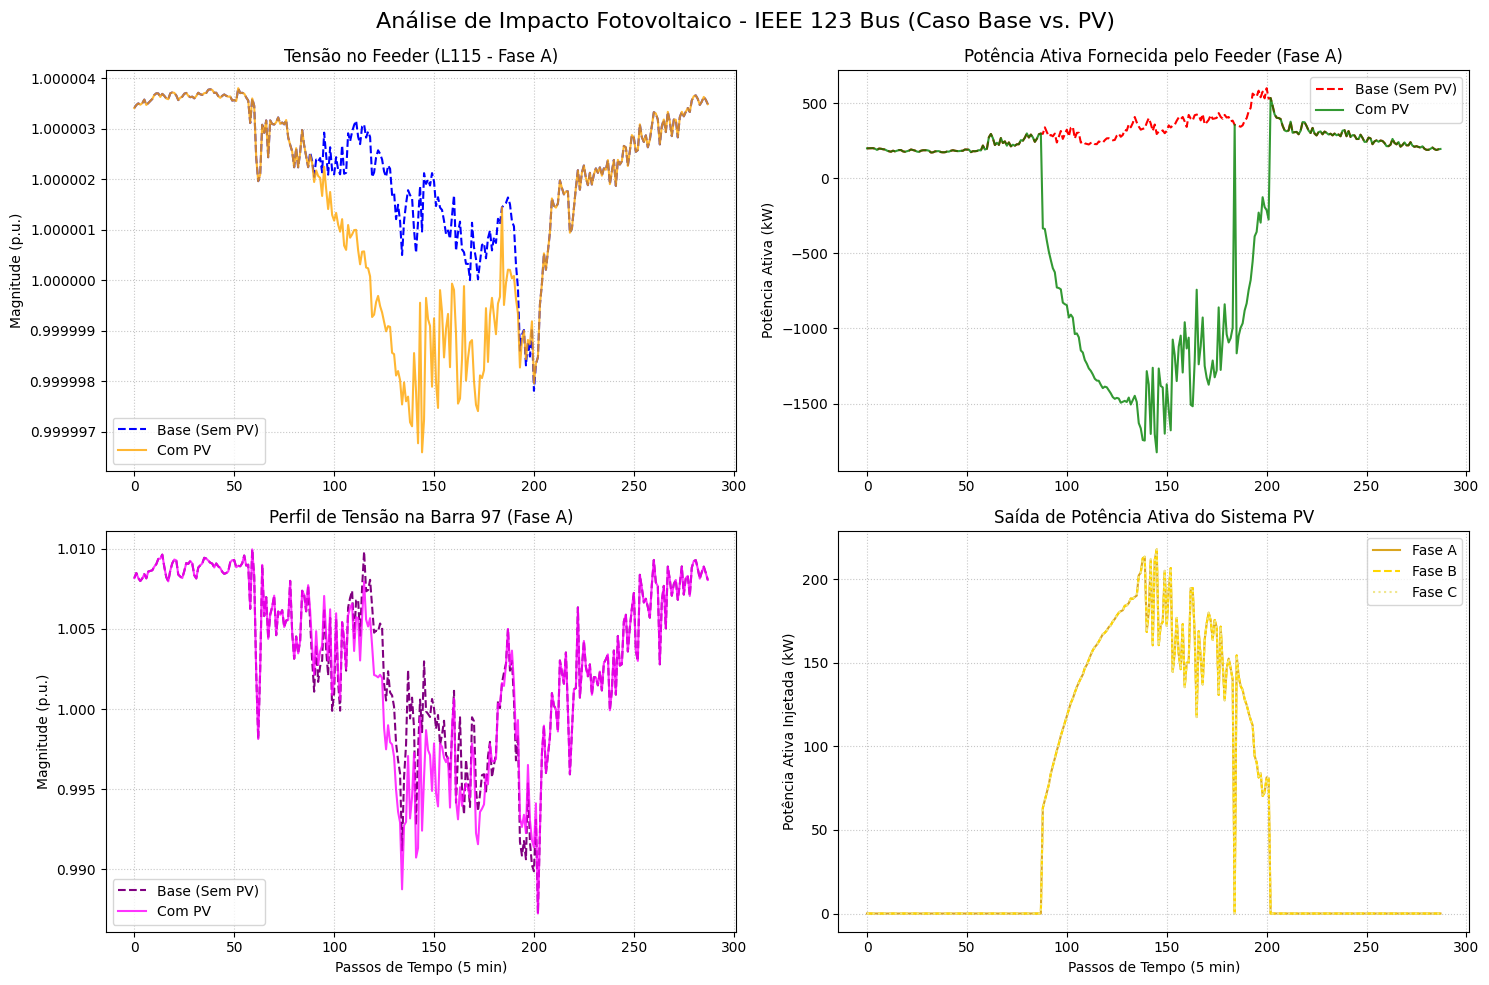

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Cria um eixo x baseado no número de pontos (passos de 5 minutos)
# Assumindo que todos os canais têm o mesmo tamanho
passos = range(len(l115_va_mag))

# Cria uma figura com uma grade 2x2 de subgráficos
fig, axs = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Análise de Impacto Fotovoltaico - IEEE 123 Bus (Caso Base vs. PV)', fontsize=16)

# 1. Comparação de Tensão no Feeder (L115 - Fase A)
axs[0, 0].plot(passos, l115_va_mag_cosim, label='Base (Sem PV)', color='blue', linestyle='--')
axs[0, 0].plot(passos, l115_va_mag_pv_cosim, label='Com PV', color='orange', alpha=0.8)
axs[0, 0].set_title('Tensão no Feeder (L115 - Fase A)')
axs[0, 0].set_ylabel('Magnitude (p.u.)')
axs[0, 0].grid(True, linestyle=':', alpha=0.7)
# Desativa o offset e a notação científica no eixo y
axs[0, 0].ticklabel_format(useOffset=False, style='plain', axis='y')
axs[0, 0].legend()

# 2. Comparação de Potência Ativa no Feeder (L115 - Fase A)
axs[0, 1].plot(passos, l115_pa_cosim, label='Base (Sem PV)', color='red', linestyle='--')
axs[0, 1].plot(passos, l115_pa_pv_cosim, label='Com PV', color='green', alpha=0.8)
axs[0, 1].set_title('Potência Ativa Fornecida pelo Feeder (Fase A)')
axs[0, 1].set_ylabel('Potência Ativa (kW)')
axs[0, 1].grid(True, linestyle=':', alpha=0.7)
axs[0, 1].legend()

# 3. Comparação de Tensão na Barra 97 (Fase A)
axs[1, 0].plot(passos, bus97_va_cosim, label='Base (Sem PV)', color='purple', linestyle='--')
axs[1, 0].plot(passos, bus97_va_pv_cosim, label='Com PV', color='magenta', alpha=0.8)
axs[1, 0].set_title('Perfil de Tensão na Barra 97 (Fase A)')
axs[1, 0].set_xlabel('Passos de Tempo (5 min)')
axs[1, 0].set_ylabel('Magnitude (p.u.)')
axs[1, 0].grid(True, linestyle=':', alpha=0.7)
axs[1, 0].legend()

# 4. Geração do Sistema PV (Potência Ativa nas 3 Fases)
axs[1, 1].plot(passos, pa_pv_cosim, label='Fase A', color='goldenrod')
axs[1, 1].plot(passos, pb_pv_cosim, label='Fase B', color='gold', linestyle='--')
axs[1, 1].plot(passos, pc_pv_cosim, label='Fase C', color='khaki', linestyle=':')
axs[1, 1].set_title('Saída de Potência Ativa do Sistema PV')
axs[1, 1].set_xlabel('Passos de Tempo (5 min)')
axs[1, 1].set_ylabel('Potência Ativa Injetada (kW)')
axs[1, 1].grid(True, linestyle=':', alpha=0.7)
axs[1, 1].legend()

# Ajusta o layout para evitar sobreposição de textos
plt.tight_layout()
plt.subplots_adjust(top=0.92) # Dá um espaço para o título principal
plt.show()

## Comparação OpenDSS puro e Co-simulação Mosaik

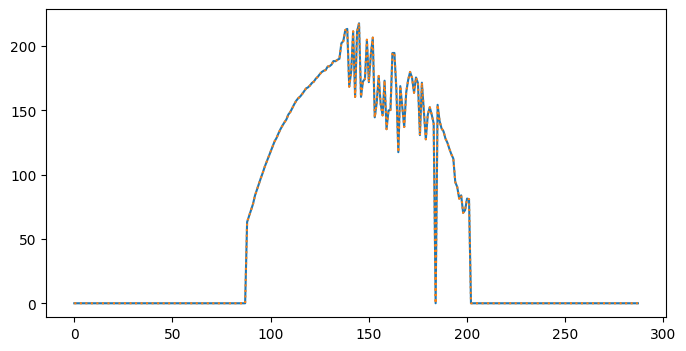

In [20]:
fig, axs = plt.subplots(1, 1, figsize=(8,4))

axs.plot(pa_pv)
axs.plot(pa_pv_cosim, linestyle=':')
# axs.plot([p/3 for p in inv_pac_cosim], linestyle=':')


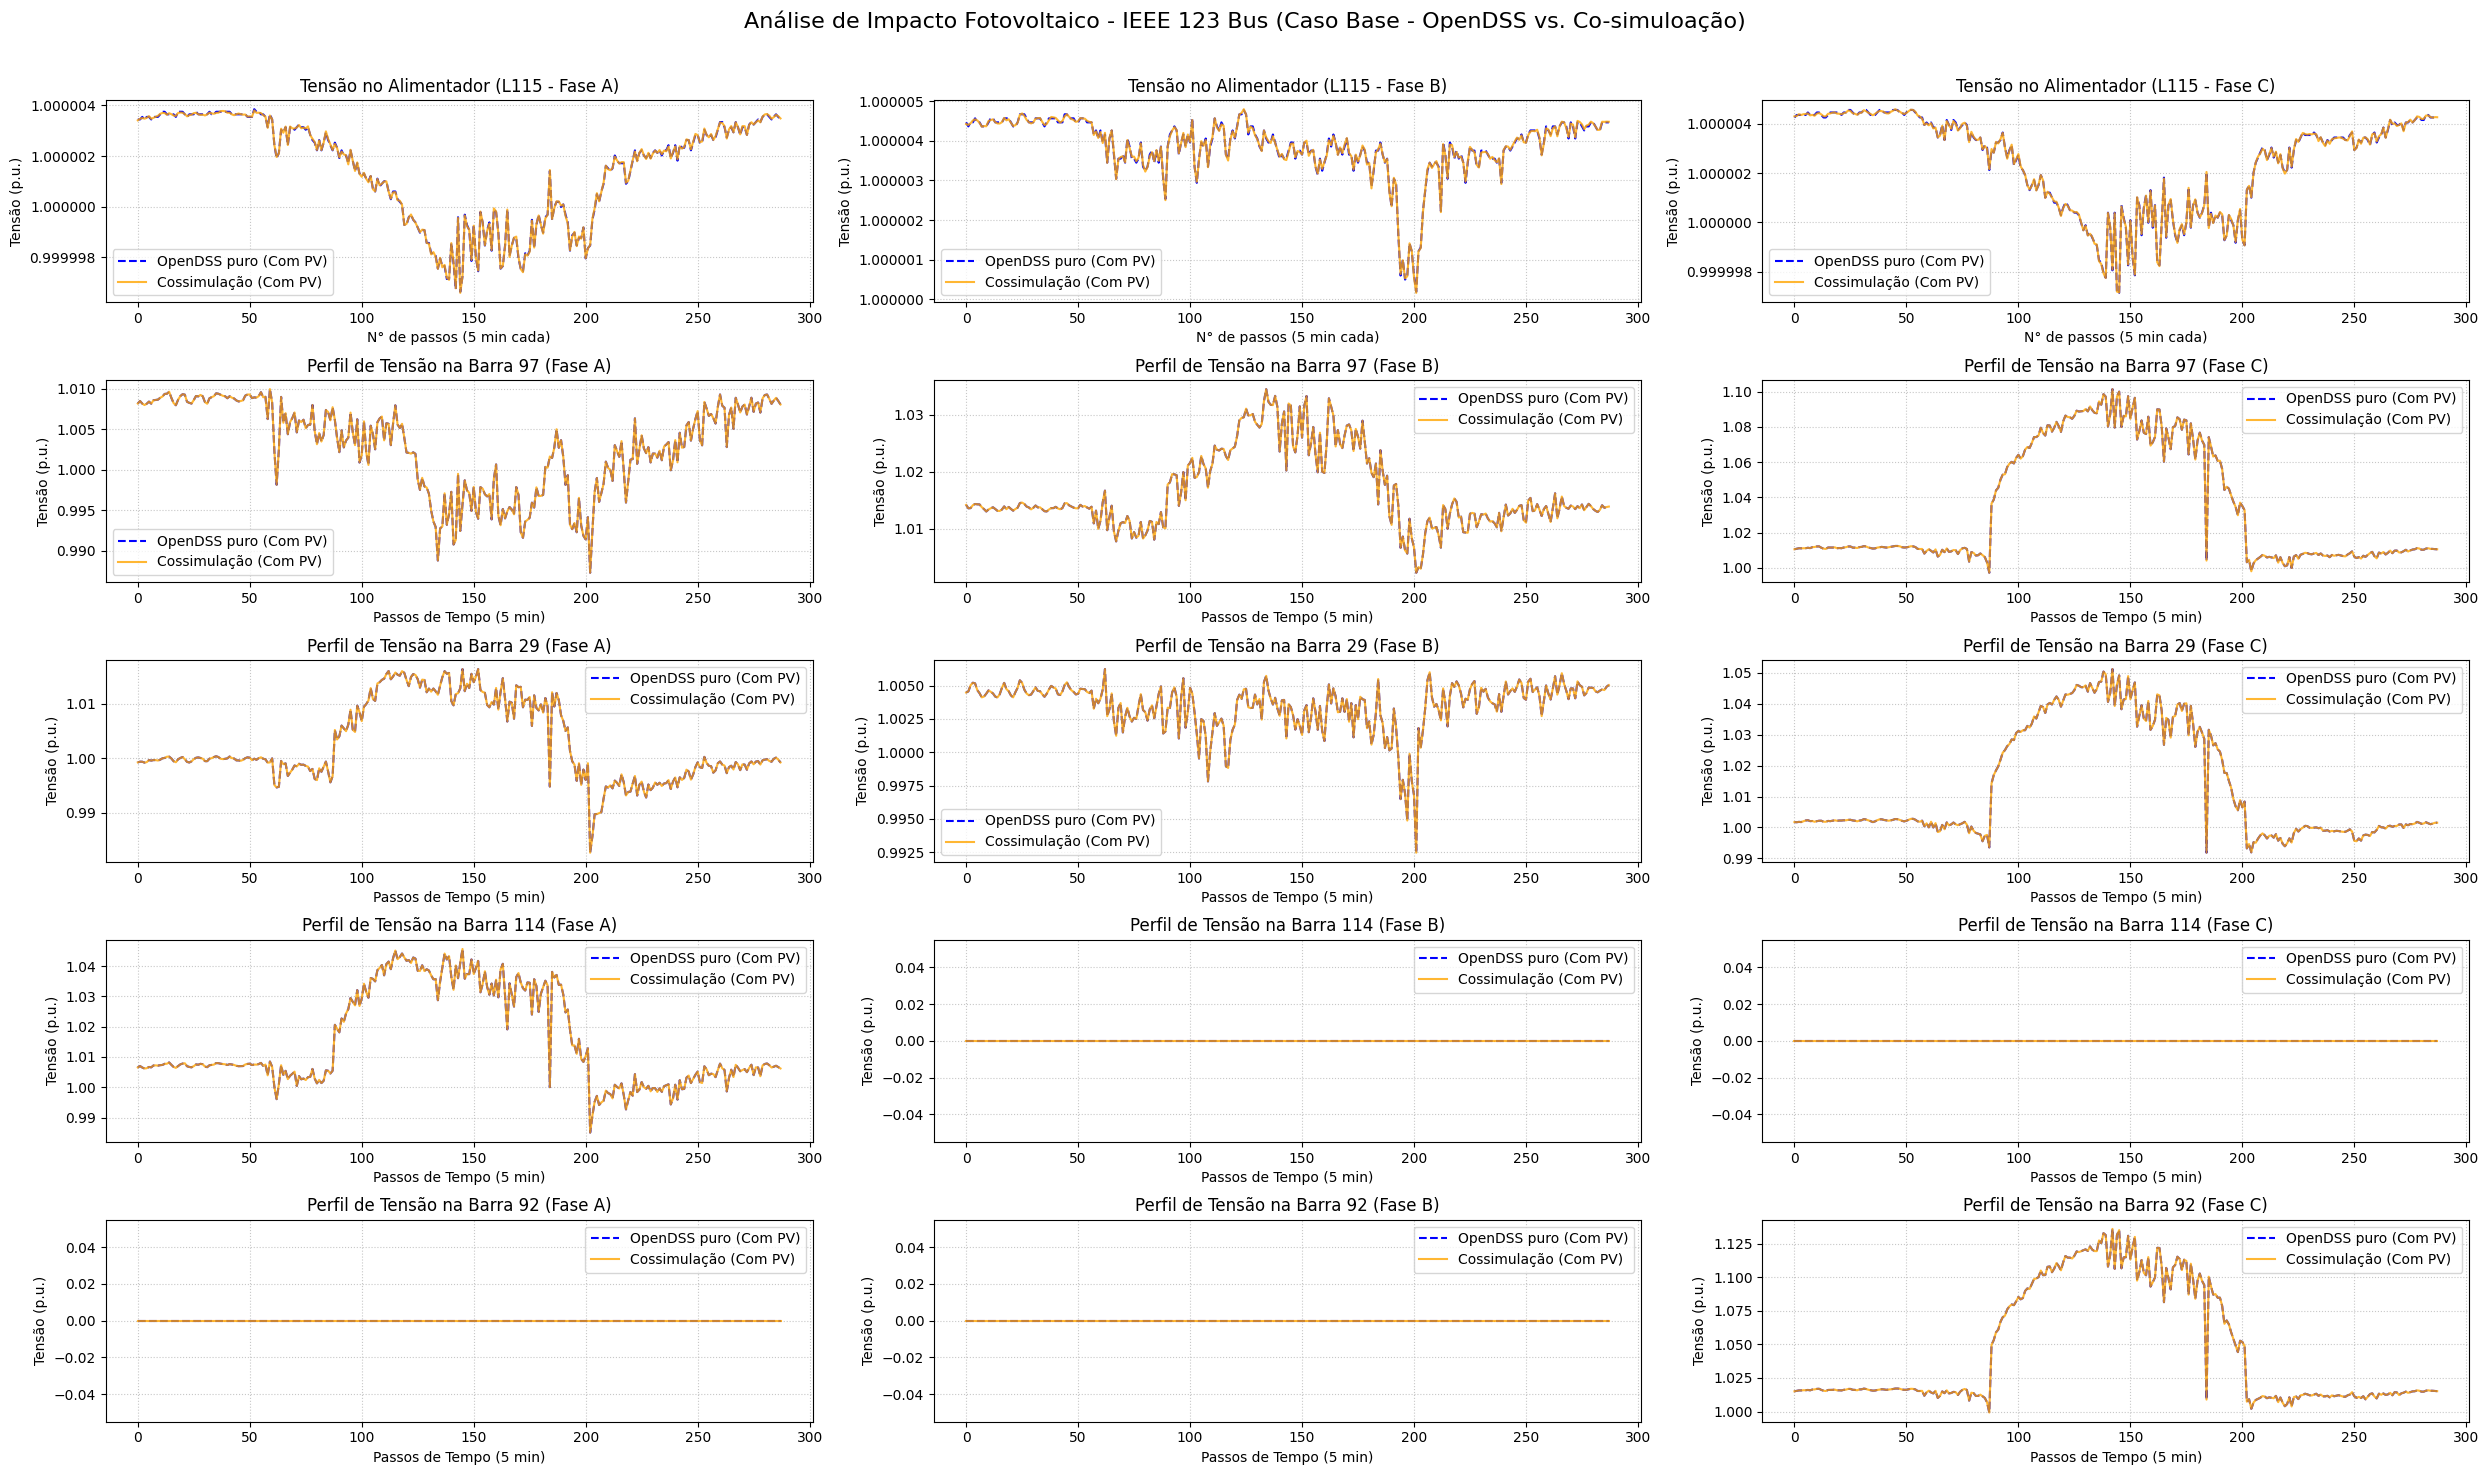

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Cria um eixo x baseado no número de pontos (passos de 5 minutos)
# Assumindo que todos os canais têm o mesmo tamanho
passos = range(len(l115_va_mag))

# Cria uma figura com uma grade 2x2 de subgráficos
fig, axs = plt.subplots(5, 3, figsize=(25, 15))
fig.suptitle('Análise de Impacto Fotovoltaico - IEEE 123 Bus (Caso Base - OpenDSS vs. Co-simuloação)', fontsize=16)

# 1. Comparação de Tensão no Feeder 
axs[0, 0].plot(passos, l115_va_mag_pv, label='OpenDSS puro (Com PV)', color='blue', linestyle='--')
axs[0, 0].plot(passos, l115_va_mag_pv_cosim, label='Cossimulação (Com PV)', color='orange', alpha=0.8)
axs[0, 0].set_title('Tensão no Alimentador (L115 - Fase A)')
axs[0, 0].set_ylabel('Tensão (p.u.)')
axs[0, 0].set_xlabel('N° de passos (5 min cada)')
axs[0, 0].grid(True, linestyle=':', alpha=0.7)
# Desativa o offset e a notação científica no eixo y
axs[0, 0].ticklabel_format(useOffset=False, style='plain', axis='y')
axs[0, 0].legend()

axs[0, 1].plot(passos, l115_vb_mag_pv, label='OpenDSS puro (Com PV)', color='blue', linestyle='--')
axs[0, 1].plot(passos, l115_vb_mag_pv_cosim, label='Cossimulação (Com PV)', color='orange', alpha=0.8)
axs[0, 1].set_title('Tensão no Alimentador (L115 - Fase B)')
axs[0, 1].set_ylabel('Tensão (p.u.)')
axs[0, 1].set_xlabel('N° de passos (5 min cada)')
axs[0, 1].grid(True, linestyle=':', alpha=0.7)
# Desativa o offset e a notação científica no eixo y
axs[0, 1].ticklabel_format(useOffset=False, style='plain', axis='y')
axs[0, 1].legend()

axs[0, 2].plot(passos, l115_vc_mag_pv, label='OpenDSS puro (Com PV)', color='blue', linestyle='--')
axs[0, 2].plot(passos, l115_vc_mag_pv_cosim, label='Cossimulação (Com PV)', color='orange', alpha=0.8)
axs[0, 2].set_title('Tensão no Alimentador (L115 - Fase C)')
axs[0, 2].set_ylabel('Tensão (p.u.)')
axs[0, 2].set_xlabel('N° de passos (5 min cada)')
axs[0, 2].grid(True, linestyle=':', alpha=0.7)
# Desativa o offset e a notação científica no eixo y
axs[0, 2].ticklabel_format(useOffset=False, style='plain', axis='y')
axs[0, 2].legend()

# --- Barra 97 ---
axs[1, 0].plot(passos, bus97_va_pv, label='OpenDSS puro (Com PV)', color='blue', linestyle='--')
axs[1, 0].plot(passos, bus97_va_pv_cosim, label='Cossimulação (Com PV)', color='orange', alpha=0.8)
axs[1, 0].set_title('Perfil de Tensão na Barra 97 (Fase A)')
axs[1, 0].set_xlabel('Passos de Tempo (5 min)')
axs[1, 0].set_ylabel('Tensão (p.u.)')
axs[1, 0].grid(True, linestyle=':', alpha=0.7)
axs[1, 0].legend()

axs[1, 1].plot(passos, bus97_vb_pv, label='OpenDSS puro (Com PV)', color='blue', linestyle='--')
axs[1, 1].plot(passos, bus97_vb_pv_cosim, label='Cossimulação (Com PV)', color='orange', alpha=0.8)
axs[1, 1].set_title('Perfil de Tensão na Barra 97 (Fase B)')
axs[1, 1].set_xlabel('Passos de Tempo (5 min)')
axs[1, 1].set_ylabel('Tensão (p.u.)')
axs[1, 1].grid(True, linestyle=':', alpha=0.7)
axs[1, 1].legend()

axs[1, 2].plot(passos, bus97_vc_pv, label='OpenDSS puro (Com PV)', color='blue', linestyle='--')
axs[1, 2].plot(passos, bus97_vc_pv_cosim, label='Cossimulação (Com PV)', color='orange', alpha=0.8)
axs[1, 2].set_title('Perfil de Tensão na Barra 97 (Fase C)')
axs[1, 2].set_xlabel('Passos de Tempo (5 min)')
axs[1, 2].set_ylabel('Tensão (p.u.)')
axs[1, 2].grid(True, linestyle=':', alpha=0.7)
axs[1, 2].legend()

# --- Barra 29 ---
axs[2, 0].plot(passos, bus29_va_pv, label='OpenDSS puro (Com PV)', color='blue', linestyle='--')
axs[2, 0].plot(passos, bus29_va_pv_cosim, label='Cossimulação (Com PV)', color='orange', alpha=0.8)
axs[2, 0].set_title('Perfil de Tensão na Barra 29 (Fase A)')
axs[2, 0].set_xlabel('Passos de Tempo (5 min)')
axs[2, 0].set_ylabel('Tensão (p.u.)')
axs[2, 0].grid(True, linestyle=':', alpha=0.7)
axs[2, 0].legend()

axs[2, 1].plot(passos, bus29_vb_pv, label='OpenDSS puro (Com PV)', color='blue', linestyle='--')
axs[2, 1].plot(passos, bus29_vb_pv_cosim, label='Cossimulação (Com PV)', color='orange', alpha=0.8)
axs[2, 1].set_title('Perfil de Tensão na Barra 29 (Fase B)')
axs[2, 1].set_xlabel('Passos de Tempo (5 min)')
axs[2, 1].set_ylabel('Tensão (p.u.)')
axs[2, 1].grid(True, linestyle=':', alpha=0.7)
axs[2, 1].legend()

axs[2, 2].plot(passos, bus29_vc_pv, label='OpenDSS puro (Com PV)', color='blue', linestyle='--')
axs[2, 2].plot(passos, bus29_vc_pv_cosim, label='Cossimulação (Com PV)', color='orange', alpha=0.8)
axs[2, 2].set_title('Perfil de Tensão na Barra 29 (Fase C)')
axs[2, 2].set_xlabel('Passos de Tempo (5 min)')
axs[2, 2].set_ylabel('Tensão (p.u.)')
axs[2, 2].grid(True, linestyle=':', alpha=0.7)
axs[2, 2].legend()

# --- Barra 114 ---
axs[3, 0].plot(passos, bus114_va_pv, label='OpenDSS puro (Com PV)', color='blue', linestyle='--')
axs[3, 0].plot(passos, bus114_va_pv_cosim, label='Cossimulação (Com PV)', color='orange', alpha=0.8)
axs[3, 0].set_title('Perfil de Tensão na Barra 114 (Fase A)')
axs[3, 0].set_xlabel('Passos de Tempo (5 min)')
axs[3, 0].set_ylabel('Tensão (p.u.)')
axs[3, 0].grid(True, linestyle=':', alpha=0.7)
axs[3, 0].legend()

axs[3, 1].plot(passos, bus114_vb_pv, label='OpenDSS puro (Com PV)', color='blue', linestyle='--')
axs[3, 1].plot(passos, bus114_vb_pv_cosim, label='Cossimulação (Com PV)', color='orange', alpha=0.8)
axs[3, 1].set_title('Perfil de Tensão na Barra 114 (Fase B)')
axs[3, 1].set_xlabel('Passos de Tempo (5 min)')
axs[3, 1].set_ylabel('Tensão (p.u.)')
axs[3, 1].grid(True, linestyle=':', alpha=0.7)
axs[3, 1].legend()

axs[3, 2].plot(passos, bus114_vc_pv, label='OpenDSS puro (Com PV)', color='blue', linestyle='--')
axs[3, 2].plot(passos, bus114_vc_pv_cosim, label='Cossimulação (Com PV)', color='orange', alpha=0.8)
axs[3, 2].set_title('Perfil de Tensão na Barra 114 (Fase C)')
axs[3, 2].set_xlabel('Passos de Tempo (5 min)')
axs[3, 2].set_ylabel('Tensão (p.u.)')
axs[3, 2].grid(True, linestyle=':', alpha=0.7)
axs[3, 2].legend()

# --- Barra 92 ---
axs[4, 0].plot(passos, bus92_va_pv, label='OpenDSS puro (Com PV)', color='blue', linestyle='--')
axs[4, 0].plot(passos, bus92_va_pv_cosim, label='Cossimulação (Com PV)', color='orange', alpha=0.8)
axs[4, 0].set_title('Perfil de Tensão na Barra 92 (Fase A)')
axs[4, 0].set_xlabel('Passos de Tempo (5 min)')
axs[4, 0].set_ylabel('Tensão (p.u.)')
axs[4, 0].grid(True, linestyle=':', alpha=0.7)
axs[4, 0].legend()

axs[4, 1].plot(passos, bus92_vb_pv, label='OpenDSS puro (Com PV)', color='blue', linestyle='--')
axs[4, 1].plot(passos, bus92_vb_pv_cosim, label='Cossimulação (Com PV)', color='orange', alpha=0.8)
axs[4, 1].set_title('Perfil de Tensão na Barra 92 (Fase B)')
axs[4, 1].set_xlabel('Passos de Tempo (5 min)')
axs[4, 1].set_ylabel('Tensão (p.u.)')
axs[4, 1].grid(True, linestyle=':', alpha=0.7)
axs[4, 1].legend()

axs[4, 2].plot(passos, bus92_vc_pv, label='OpenDSS puro (Com PV)', color='blue', linestyle='--')
axs[4, 2].plot(passos, bus92_vc_pv_cosim, label='Cossimulação (Com PV)', color='orange', alpha=0.8)
axs[4, 2].set_title('Perfil de Tensão na Barra 92 (Fase C)')
axs[4, 2].set_xlabel('Passos de Tempo (5 min)')
axs[4, 2].set_ylabel('Tensão (p.u.)')
axs[4, 2].grid(True, linestyle=':', alpha=0.7)
axs[4, 2].legend()

# Ajusta o layout para evitar sobreposição de textos
plt.tight_layout()
plt.subplots_adjust(top=0.92) # Dá um espaço para o título principal
plt.show()

In [26]:
# ==============================================================================
# ALGORITMO DE CÁLCULO DE MÉTRICAS DE ERRO (PURO PYTHON)
# ==============================================================================

def calcular_rmse_mae(lista_referencia, lista_medicao):
    """
    Calcula o RMSE e o MAE entre duas listas de valores sem usar bibliotecas.
    lista_referencia: Valores do OpenDSS puro (Ground Truth).
    lista_medicao: Valores da Co-simulação no Mosaik.
    """
    # Garantir que as listas são do tipo list (convertendo de pandas Series se necessário)
    ref = list(lista_referencia)
    med = list(lista_medicao)
    
    # Alinhar tamanhos caso as simulações tenham diferença de 1 step no final
    tamanho = min(len(ref), len(med))
    if tamanho == 0:
        return None, None
        
    soma_erros_quadrados = 0.0
    soma_erros_absolutos = 0.0
    
    for i in range(tamanho):
        erro = ref[i] - med[i]
        soma_erros_quadrados += erro ** 2
        soma_erros_absolutos += abs(erro)
        
    mse = soma_erros_quadrados / tamanho
    rmse = mse ** 0.5  # Raiz quadrada sem usar math.sqrt
    mae = soma_erros_absolutos / tamanho
    
    return rmse, mae

# ==============================================================================
# MAPEAMENTO DAS CURVAS COMPARÁVEIS
# ==============================================================================

# Dicionário organizando o Nome da Grandeza, Curva OpenDSS e Curva Mosaik.
# Obs: Descartei variáveis internas do Mosaik que não foram extraídas do 
# OpenDSS puro (ex: temperature_cosim, pv_dc_cosim).

comparacoes = {
    # # --- CASO 1: SEM PV (IEEE 123 Original) ---
    # "Tensão Bus 149 (Fase A) [pu]": (l115_va_mag, l115_va_mag_cosim),
    # "Tensão Bus 149 (Fase B) [pu]": (l115_vb_mag, l115_vb_mag_cosim),
    # "Tensão Bus 149 (Fase C) [pu]": (l115_vc_mag, l115_vc_mag_cosim),
    
    # "Tensão Bus 97 (Fase A) [pu] ": (bus97_va, bus97_va_cosim),
    # "Tensão Bus 97 (Fase B) [pu] ": (bus97_vb, bus97_vb_cosim),
    # "Tensão Bus 97 (Fase C) [pu] ": (bus97_vc, bus97_vc_cosim),
    
    # "Potência Ativa L115 (Fase A) [kW]": (l115_pa, l115_pa_cosim),
    # "Pot. Reativa L115 (Fase A) [kvar]": (l115_qa, l115_qa_cosim),
    # # Você pode adicionar as Fases B e C da linha 115 aqui se desejar...

    # --- CASO 2: COM PV INTEGRADO ---
    "PV_Tensão Bus 149 (Fase A) [pu]": (l115_va_mag_pv, l115_va_mag_pv_cosim),
    "PV_Tensão Bus 149 (Fase B) [pu]": (l115_vb_mag_pv, l115_vb_mag_pv_cosim),
    "PV_Tensão Bus 149 (Fase C) [pu]": (l115_vc_mag_pv, l115_vc_mag_pv_cosim),
    # --- BUS 97 ---
    "PV_Tensão Bus 97 (Fase A) [pu] ": (bus97_va_pv, bus97_va_pv_cosim),
    "PV_Tensão Bus 97 (Fase B) [pu] ": (bus97_vb_pv, bus97_vb_pv_cosim),
    "PV_Tensão Bus 97 (Fase C) [pu] ": (bus97_vc_pv, bus97_vc_pv_cosim),

    # --- BUS 29 ---
    "PV_Tensão Bus 29 (Fase A) [pu] ": (bus29_va_pv, bus29_va_pv_cosim),
    "PV_Tensão Bus 29 (Fase B) [pu] ": (bus29_vb_pv, bus29_vb_pv_cosim),
    "PV_Tensão Bus 29 (Fase C) [pu] ": (bus29_vc_pv, bus29_vc_pv_cosim),

    # --- BUS 114 ---
    "PV_Tensão Bus 114 (Fase A) [pu]": (bus114_va_pv, bus114_va_pv_cosim),
    "PV_Tensão Bus 114 (Fase B) [pu]": (bus114_vb_pv, bus114_vb_pv_cosim),
    "PV_Tensão Bus 114 (Fase C) [pu]": (bus114_vc_pv, bus114_vc_pv_cosim),

    # --- BUS 92 ---
    "PV_Tensão Bus 92 (Fase A) [pu] ": (bus92_va_pv, bus92_va_pv_cosim),
    "PV_Tensão Bus 92 (Fase B) [pu] ": (bus92_vb_pv, bus92_vb_pv_cosim),
    "PV_Tensão Bus 92 (Fase C) [pu] ": (bus92_vc_pv, bus92_vc_pv_cosim),
    
    # "PV_Potência Ativa L115 (Fase A) [kW]": (l115_pa_pv, l115_pa_pv_cosim),
    
    # "PV_Geração Ativa Bus 97 (Fase A) [kW]  ": (pa_pv, pa_pv_cosim),
    # "PV_Geração Ativa Bus 97 (Fase B) [kW]  ": (pb_pv, pb_pv_cosim),
    # "PV_Geração Ativa Bus 97 (Fase C) [kW]  ": (pc_pv, pc_pv_cosim),
    
    # "PV_Geração Reativa Bus 97 (Fase A) [kvar]": (qa_pv, qa_pv_cosim),
    # "PV_Geração Reativa Bus 97 (Fase B) [kvar]": (qb_pv, qb_pv_cosim),
    # "PV_Geração Reativa Bus 97 (Fase C) [kvar]": (qc_pv, qc_pv_cosim),
}

# ==============================================================================
# EXECUÇÃO E RELATÓRIO
# ==============================================================================

print("="*80)
print(f"{'RELATÓRIO DE ERROS: OPENDSS PURO vs MOSAIK CO-SIMULATION':^80}")
print("="*80)
print(f"{'Grandeza Analisada':<40} | {'RMSE':<15} | {'MAE':<15}")
print("-" * 80)

for nome_grandeza, (curva_ref, curva_med) in comparacoes.items():
    rmse, mae = calcular_rmse_mae(curva_ref, curva_med)
    
    if rmse is not None:
        # Formatando para notação científica caso o erro seja muito pequeno
        # ou fixando em 6 casas decimais
        print(f"{nome_grandeza:<40} | {rmse:<15.6f} | {mae:<15.6f}")
    else:
        print(f"{nome_grandeza:<40} | {'ERRO DE DADOS':<15} | {'ERRO DE DADOS':<15}")

print("="*80)

            RELATÓRIO DE ERROS: OPENDSS PURO vs MOSAIK CO-SIMULATION            
Grandeza Analisada                       | RMSE            | MAE            
--------------------------------------------------------------------------------
PV_Tensão Bus 149 (Fase A) [pu]          | 0.000000        | 0.000000       
PV_Tensão Bus 149 (Fase B) [pu]          | 0.000000        | 0.000000       
PV_Tensão Bus 149 (Fase C) [pu]          | 0.000000        | 0.000000       
PV_Tensão Bus 97 (Fase A) [pu]           | 0.000003        | 0.000002       
PV_Tensão Bus 97 (Fase B) [pu]           | 0.000003        | 0.000002       
PV_Tensão Bus 97 (Fase C) [pu]           | 0.000005        | 0.000002       
PV_Tensão Bus 29 (Fase A) [pu]           | 0.000002        | 0.000001       
PV_Tensão Bus 29 (Fase B) [pu]           | 0.000002        | 0.000001       
PV_Tensão Bus 29 (Fase C) [pu]           | 0.000002        | 0.000001       
PV_Tensão Bus 114 (Fase A) [pu]          | 0.000005        | 0.00000